# Tema B · Interés Simple

**Curso: Matemáticas Financieras** — Notebook de aplicación práctica

Este notebook cubre el **Tema B del temario** (*Interés simple*):

- Cálculo de interés y monto (valor futuro) con tasa fija y con tasa variable
- Cálculo de valor presente
- Despeje de tasa de interés y de tiempo

Y lo lleva a **casos de análisis empresarial y de inversiones**: costo de financiamiento
de corto plazo, descuentos por pronto pago y valuación de instrumentos de descuento
(CETES, papel comercial).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


## Valor futuro (monto) con interés simple

El interés simple se calcula **solo sobre el capital inicial**, sin reinvertir los
intereses generados en periodos previos:

$$
I = PV \cdot i \cdot n \qquad\qquad FV = PV + I = PV \cdot (1 + i \cdot n)
$$

Donde:
- $PV$ = valor presente o inversión inicial
- $i$ = tasa de interés ajustada al periodo
- $n$ = número de periodos


In [2]:
def interes_simple(pv, i, n):
    '''I = PV * i * n'''
    return pv * i * n


def valor_futuro_simple(pv, i, n):
    '''FV = PV * (1 + i*n)'''
    return pv * (1 + i * n)


### Ejercicio (slides): valor futuro con tasa fija

> ¿Cuál será el valor futuro de 12,000 invertidos a 16 meses si la tasa de interés es
> del 17% (anual)?

Resultado esperado: **14,720**.


In [3]:
pv = 12_000
tasa_anual = 0.17
meses = 16
i_mensual = tasa_anual / 12

fv = valor_futuro_simple(pv, i_mensual, meses)
print(f"Valor futuro: {fv:,.2f}")
assert round(fv, 2) == 14_720.00
print("OK: coincide con las slides.")


Valor futuro: 14,720.00
OK: coincide con las slides.


### Ejercicio (slides): inversión que no reinvierte intereses

> ¿Cuál será el valor futuro de una inversión que nos paga 14% cuatrimestral si no se
> reinvierten nunca los intereses y se deja la inversión durante los siguientes 2 años
> (por cada peso invertido)?

Resultado esperado: **1.84** por cada peso invertido.


In [4]:
pv = 1
i_cuatrimestral = 0.14
n_cuatrimestres = 6  # 2 años = 6 cuatrimestres

fv = valor_futuro_simple(pv, i_cuatrimestral, n_cuatrimestres)
print(f"Valor futuro (por peso invertido): {fv:,.2f}")
assert round(fv, 2) == 1.84
print("OK: coincide con las slides.")


Valor futuro (por peso invertido): 1.84
OK: coincide con las slides.


## Valor futuro con tasa variable

Cuando la tasa cambia en cada periodo y **no se reinvierten** los intereses, el valor
futuro se calcula sumando las tasas de cada periodo:

$$
FV = PV \cdot \left(1 + (i_1 + i_2 + \dots + i_n)\right)
$$


In [5]:
def valor_futuro_simple_tasa_variable(pv, tasas):
    '''FV = PV * (1 + sum(tasas)), útil cuando no se reinvierten los intereses
    y la tasa cambia periodo a periodo.'''
    return pv * (1 + sum(tasas))


### Ejercicio (slides)

> ¿Cuál será el valor futuro al término de 3 años de una inversión de \$200,000 si nunca
> reinvierto los intereses y las tasas de interés son del 17%, 21% y 15% para cada año
> respectivamente?

Resultado esperado: **306,000**.


In [6]:
pv = 200_000
tasas = [0.17, 0.21, 0.15]

fv = valor_futuro_simple_tasa_variable(pv, tasas)
print(f"Valor futuro: {fv:,.2f}")
assert round(fv, 2) == 306_000.00
print("OK: coincide con las slides.")


Valor futuro: 306,000.00
OK: coincide con las slides.


## Valor presente con interés simple

Despejando la fórmula del valor futuro:

$$
PV = \frac{FV}{1 + i \cdot n}
$$


In [7]:
def valor_presente_simple(fv, i, n):
    '''PV = FV / (1 + i*n)'''
    return fv / (1 + i * n)


### Ejercicio (slides)

> ¿Cuánto dinero deberé invertir hoy si quiero obtener \$6,000,000 dentro de 3 años y hay
> instrumentos que pagan un interés sobre el capital invertido del 23% (sin reinversión
> de intereses)?

Resultado esperado (slides): **≈ 3,550,290**.


In [8]:
fv = 6_000_000
i = 0.23
n = 3

pv = valor_presente_simple(fv, i, n)
print(f"Valor presente: {pv:,.2f}")
# El valor exacto es 3,550,295.86; las slides lo reportan redondeado a 3,550,290.
assert abs(pv - 3_550_295.86) < 1
print("OK: coincide (salvo un pequeño redondeo del material original) con las slides.")


Valor presente: 3,550,295.86
OK: coincide (salvo un pequeño redondeo del material original) con las slides.


## Despeje de tasa y de tiempo (interés simple)

$$
t = \dfrac{\frac{FV}{PV} - 1}{i} \qquad\qquad
i = \dfrac{\frac{FV}{PV} - 1}{t}
$$


In [9]:
def tiempo_simple(fv, pv, i):
    '''t = (FV/PV - 1) / i'''
    return (fv / pv - 1) / i


def tasa_simple(fv, pv, t):
    '''i = (FV/PV - 1) / t'''
    return (fv / pv - 1) / t


### Ejercicios (slides)

> ¿Cuánto tiempo tendré que dejar una inversión para triplicar su valor si existe una
> tasa de interés en el mercado con la que puedo ganar del 1.9% mensual?

> ¿Cuál es la tasa de interés que se requiere para que en 17 meses un valor de \$100,000
> invertidos se conviertan en \$127,890?


In [10]:
t = tiempo_simple(fv=3, pv=1, i=0.019)
print(f"Tiempo para triplicar el valor: {t:.2f} meses")
assert round(t, 2) == 105.26

i = tasa_simple(fv=127_890, pv=100_000, t=17)
print(f"Tasa mensual requerida: {i:.6f} ({i:.4%})")
assert round(i, 6) == 0.016406

print("\nOK: ambos resultados coinciden con las slides.")


Tiempo para triplicar el valor: 105.26 meses
Tasa mensual requerida: 0.016406 (1.6406%)

OK: ambos resultados coinciden con las slides.


## Caso empresarial: costo de un descuento por pronto pago ("2/10, neto 30")

Es muy común que un proveedor ofrezca condiciones del tipo **"2/10 neto 30"**: 2% de
descuento si se paga en 10 días, o el 100% del importe si se paga a 30 días. **No tomar
el descuento equivale a pedir un préstamo implícito** al proveedor durante los 20 días
adicionales.

Podemos modelarlo con interés simple: pagar \$98 hoy es equivalente a pagar \$100 en 20
días más, así que buscamos la tasa simple periódica implícita de esos 20 días y luego la
anualizamos, para compararla contra el costo de una línea de crédito bancaria.


In [11]:
def costo_anual_descuento_pronto_pago(descuento, dias_descuento, dias_credito, dias_anio=360):
    '''Anualiza (interés simple) el costo de NO tomar un descuento por pronto pago.

    - descuento: proporción del descuento ofrecido (p.ej. 0.02 para 2%)
    - dias_descuento: días para pagar y obtener el descuento
    - dias_credito: días totales de crédito del proveedor
    '''
    pv = 1 - descuento          # lo que se paga si se toma el descuento
    fv = 1                      # lo que se paga si se espera al vencimiento
    dias_prestamo_implicito = dias_credito - dias_descuento
    i_periodo = tasa_simple(fv, pv, t=1)          # tasa del periodo de "préstamo" implícito
    i_anual = i_periodo * (dias_anio / dias_prestamo_implicito)
    return i_periodo, i_anual


i_periodo, i_anual = costo_anual_descuento_pronto_pago(descuento=0.02, dias_descuento=10, dias_credito=30)
tasa_linea_credito = 0.22  # tasa anual simple que ofrece el banco

print(f"Costo del periodo de 20 días por no tomar el descuento: {i_periodo:.4%}")
print(f"Costo ANUALIZADO (interés simple) de no tomar el descuento: {i_anual:.4%}")
print(f"Costo de la línea de crédito bancaria (referencia):        {tasa_linea_credito:.4%}")

if i_anual > tasa_linea_credito:
    print("\nConclusión: conviene usar la línea de crédito para pagar pronto y tomar el "
          "descuento del proveedor (el descuento 'cuesta' más que el crédito bancario).")
else:
    print("\nConclusión: conviene NO tomar el descuento y financiarse con el proveedor.")


Costo del periodo de 20 días por no tomar el descuento: 2.0408%
Costo ANUALIZADO (interés simple) de no tomar el descuento: 36.7347%
Costo de la línea de crédito bancaria (referencia):        22.0000%

Conclusión: conviene usar la línea de crédito para pagar pronto y tomar el descuento del proveedor (el descuento 'cuesta' más que el crédito bancario).


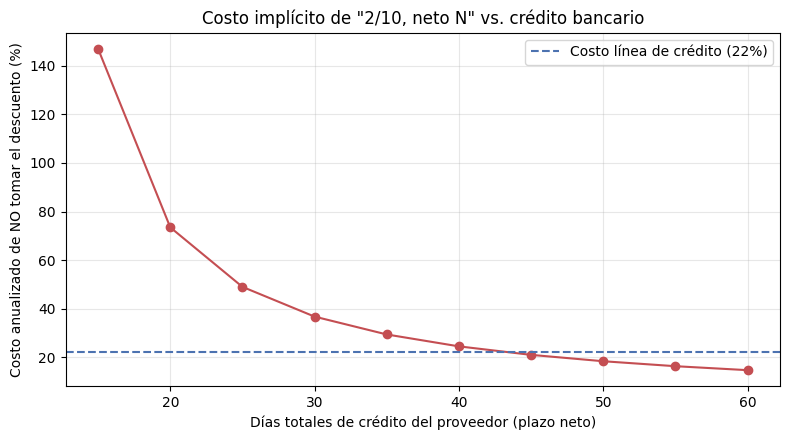

In [12]:
# Sensibilidad: costo anualizado del descuento para distintos plazos de crédito del proveedor
plazos = np.arange(15, 61, 5)
costos = [costo_anual_descuento_pronto_pago(0.02, 10, d)[1] for d in plazos]

fig, ax = plt.subplots()
ax.plot(plazos, np.array(costos) * 100, marker="o", color="#C44E52")
ax.axhline(tasa_linea_credito * 100, color="#4C72B0", linestyle="--", label="Costo línea de crédito (22%)")
ax.set_xlabel("Días totales de crédito del proveedor (plazo neto)")
ax.set_ylabel("Costo anualizado de NO tomar el descuento (%)")
ax.set_title('Costo implícito de "2/10, neto N" vs. crédito bancario')
ax.legend()
plt.tight_layout()
plt.show()


## Caso de inversión: rendimiento de instrumentos a descuento (CETES / papel comercial)

Los CETES y el papel comercial se cotizan **a descuento**: se compran por debajo de su
valor nominal y pagan el nominal al vencimiento; no pagan cupón. Podemos usar las mismas
fórmulas de interés simple para obtener el rendimiento implícito (tasa de rendimiento) a
partir del precio de compra, y comparar contra otras alternativas de inversión de corto
plazo.


In [13]:
def rendimiento_instrumento_descuento(valor_nominal, precio_compra, dias_vencimiento, dias_anio=360):
    '''Tasa de rendimiento simple anualizada de un instrumento comprado a descuento.'''
    t_anual = dias_vencimiento / dias_anio
    return tasa_simple(fv=valor_nominal, pv=precio_compra, t=t_anual)


instrumentos = pd.DataFrame({
    "Instrumento": ["CETES 28 días", "CETES 91 días", "Papel comercial 60 días"],
    "Valor nominal": [10, 10, 100_000],
    "Precio de compra": [9.9180, 9.7550, 98_500],
    "Días al vencimiento": [28, 91, 60],
})

instrumentos["Rendimiento anual (simple)"] = instrumentos.apply(
    lambda r: rendimiento_instrumento_descuento(r["Valor nominal"], r["Precio de compra"], r["Días al vencimiento"]),
    axis=1,
)
instrumentos["Rendimiento anual (%)"] = (instrumentos["Rendimiento anual (simple)"] * 100).round(3)
instrumentos[["Instrumento", "Valor nominal", "Precio de compra", "Días al vencimiento", "Rendimiento anual (%)"]]


,Instrumento,Valor nominal,Precio de compra,Días al vencimiento,Rendimiento anual (%)
0,CETES 28 días,10,9.918000,28,10.630000
1,CETES 91 días,10,9.755000,91,9.936000
2,Papel comercial 60 días,100000,"98,500.000000",60,9.137000


## Resumen de funciones del notebook

| Función | Uso |
|---|---|
| `interes_simple(pv, i, n)` | Interés generado en interés simple |
| `valor_futuro_simple(pv, i, n)` | Monto (FV) con tasa fija |
| `valor_futuro_simple_tasa_variable(pv, tasas)` | Monto (FV) con tasas distintas por periodo, sin reinversión |
| `valor_presente_simple(fv, i, n)` | Valor presente con tasa fija |
| `tiempo_simple(fv, pv, i)` / `tasa_simple(fv, pv, t)` | Despeje de tiempo y de tasa |
| `costo_anual_descuento_pronto_pago(...)` | Costo anualizado de no tomar un descuento comercial |
| `rendimiento_instrumento_descuento(...)` | Rendimiento implícito de instrumentos que cotizan a descuento |

## Ejercicios propuestos

1. Un proveedor ofrece "3/15, neto 45". Calcula el costo anualizado de no tomar el
   descuento y compáralo con una línea de crédito revolvente al 24% anual.
2. Una empresa compra papel comercial a 91 días con valor nominal de \$1,000,000 en
   \$965,000. ¿Cuál es su rendimiento anual simple? ¿Cómo se compara contra un CETE al
   mismo plazo que rinde 10.8%?
3. Calcula cuánto tiempo (en meses) le tomaría a una inversión duplicar su valor con una
   tasa simple del 2.3% mensual, usando `tiempo_simple`.
